# Clasificador de Vinos con KNN

En este proyecto se entrena un modelo de K-Vecinos mas Cercanos (KNN) para predecir la calidad de un vino tinto a partir de sus caracteristicas quimicas.

El flujo sigue la estructura solicitada por 4Geeks:

- Carga y exploracion del dataset.
- Preparacion de la variable objetivo `label`.
- Separacion entre variables predictoras y objetivo.
- Division train/test.
- Escalado de datos, necesario para KNN.
- Entrenamiento y evaluacion del modelo.
- Optimizacion del valor de `k`.
- Guardado de resultados y modelos.
- Creacion de una funcion para predecir la calidad de nuevos vinos.

## 1. Carga del conjunto de datos

In [1]:
%matplotlib inline

from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 50)

ROOT_DIR = Path.cwd().parent if Path.cwd().name == "src" else Path.cwd()
DATA_URL = "https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv"
RAW_DATA_PATH = ROOT_DIR / "data" / "raw" / "winequality-red.csv"
PROCESSED_DATA_PATH = ROOT_DIR / "data" / "processed" / "winequality_red_labeled.csv"
K_RESULTS_PATH = ROOT_DIR / "data" / "processed" / "knn_k_results.csv"
MODEL_RESULTS_PATH = ROOT_DIR / "data" / "processed" / "model_results.csv"
KNN_MODEL_PATH = ROOT_DIR / "models" / "wine_quality_knn.pkl"
BEST_MODEL_PATH = ROOT_DIR / "models" / "wine_quality_best_model.pkl"

RAW_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
KNN_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

if RAW_DATA_PATH.exists():
    df = pd.read_csv(RAW_DATA_PATH, sep=";")
else:
    df = pd.read_csv(DATA_URL, sep=";")
    df.to_csv(RAW_DATA_PATH, index=False, sep=";")

print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
display(df.head())

Filas: 1599 | Columnas: 12


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


El archivo original viene separado por punto y coma. La columna original del dataset UCI es `quality`, con valores de calidad numericos. Para cumplir el enunciado, se transforma en `label` con tres categorias.

## 2. Exploracion y preparacion de variables

In [2]:
summary = pd.DataFrame({
    "tipo": df.dtypes,
    "nulos": df.isna().sum(),
    "valores_unicos": df.nunique(),
})

display(summary)
print(f"Duplicados exactos: {df.duplicated().sum()}")
display(df["quality"].value_counts().sort_index().rename("conteo").to_frame())

,tipo,nulos,valores_unicos
fixed acidity,float64,0,96
volatile acidity,float64,0,143
citric acid,float64,0,80
residual sugar,float64,0,91
chlorides,float64,0,153
free sulfur dioxide,float64,0,60
total sulfur dioxide,float64,0,144
density,float64,0,436
pH,float64,0,89
sulphates,float64,0,96


Duplicados exactos: 240


,conteo
quality,
3,10
4,53
5,681
6,638
7,199
8,18


In [3]:
def quality_to_label(quality):
    if quality <= 4:
        return 0
    if quality <= 6:
        return 1
    return 2

label_names = {
    0: "Baja calidad",
    1: "Calidad media",
    2: "Alta calidad",
}

clean_df = df.drop_duplicates().reset_index(drop=True).copy()
clean_df["label"] = clean_df["quality"].apply(quality_to_label)
clean_df["label_name"] = clean_df["label"].map(label_names)
clean_df.to_csv(PROCESSED_DATA_PATH, index=False)

print(f"Dataset procesado: {clean_df.shape[0]} filas y {clean_df.shape[1]} columnas")
display(clean_df.head())
display(clean_df["label_name"].value_counts().rename("conteo").to_frame())

Dataset procesado: 1359 filas y 14 columnas


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,label,label_name
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1,Calidad media
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1,Calidad media
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1,Calidad media
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1,Calidad media
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,1,Calidad media


,conteo
label_name,
Calidad media,1112
Alta calidad,184
Baja calidad,63


La clase mayoritaria es la calidad media. Esto es importante al interpretar las metricas: una accuracy alta puede ocultar dificultades para clasificar vinos de baja calidad, porque hay pocos ejemplos de esa clase.

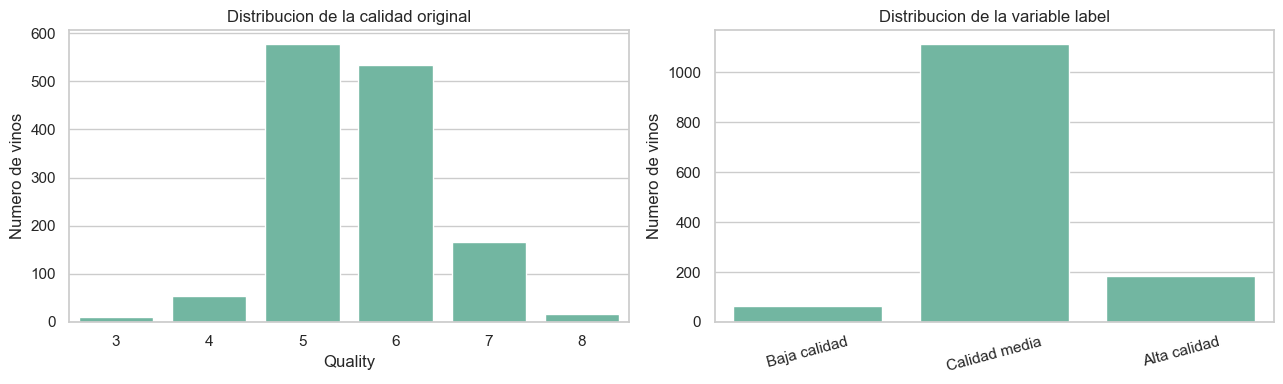

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.countplot(data=clean_df, x="quality", ax=axes[0])
axes[0].set_title("Distribucion de la calidad original")
axes[0].set_xlabel("Quality")
axes[0].set_ylabel("Numero de vinos")

order = ["Baja calidad", "Calidad media", "Alta calidad"]
sns.countplot(data=clean_df, x="label_name", order=order, ax=axes[1])
axes[1].set_title("Distribucion de la variable label")
axes[1].set_xlabel("")
axes[1].set_ylabel("Numero de vinos")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

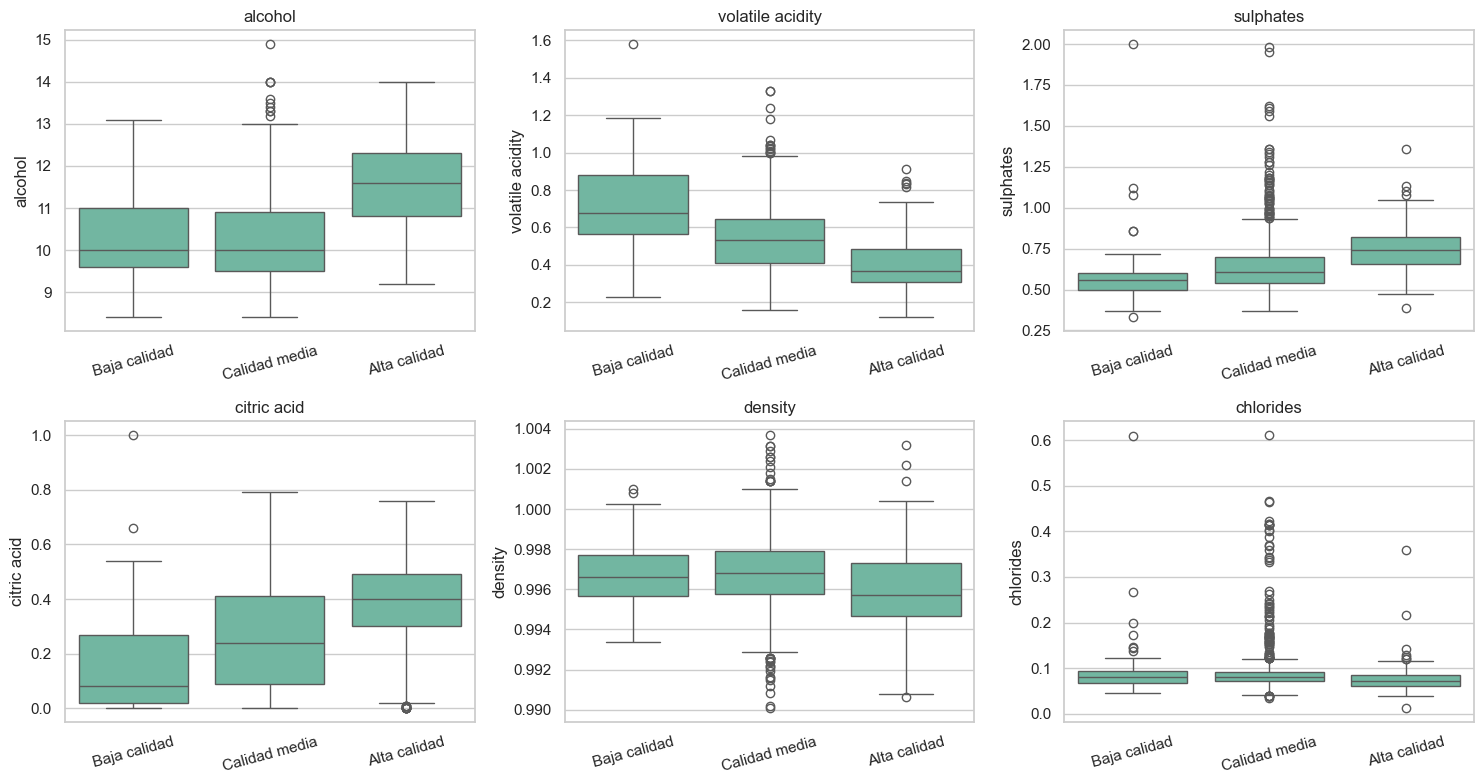

In [5]:
feature_columns = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar",
    "chlorides",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol",
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
selected_features = ["alcohol", "volatile acidity", "sulphates", "citric acid", "density", "chlorides"]

for ax, column in zip(axes.ravel(), selected_features):
    sns.boxplot(data=clean_df, x="label_name", y=column, order=order, ax=ax)
    ax.set_title(column)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

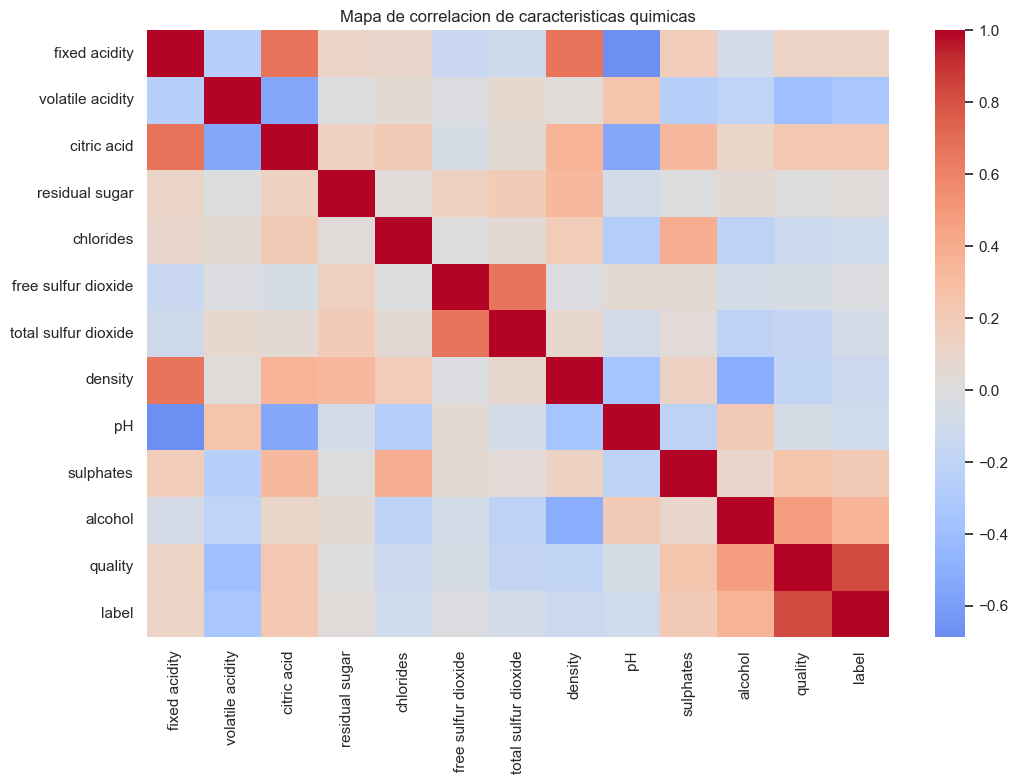

,correlacion_con_quality
alcohol,0.480343
sulphates,0.248835
citric acid,0.228057
fixed acidity,0.119024
residual sugar,0.013640
free sulfur dioxide,-0.050463
pH,-0.055245
chlorides,-0.130988
total sulfur dioxide,-0.177855
density,-0.184252


In [6]:
plt.figure(figsize=(11, 8))
correlation = clean_df[feature_columns + ["quality", "label"]].corr(numeric_only=True)
sns.heatmap(correlation, cmap="coolwarm", center=0, annot=False)
plt.title("Mapa de correlacion de caracteristicas quimicas")
plt.tight_layout()
plt.show()

correlation_with_quality = correlation["quality"].drop(["quality", "label"]).sort_values(ascending=False)
display(correlation_with_quality.to_frame("correlacion_con_quality"))

Variables como `alcohol`, `sulphates` y `volatile acidity` muestran una relacion visible con la calidad. KNN no aprende coeficientes como una regresion, pero estas diferencias en el espacio de variables influyen en la cercania entre vinos.

## 3. Entrenamiento inicial del modelo KNN

In [7]:
X = clean_df[feature_columns]
y = clean_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(f"Train: {X_train.shape[0]} vinos | Test: {X_test.shape[0]} vinos")
print("Distribucion train:")
display(y_train.map(label_names).value_counts().to_frame("conteo"))
print("Distribucion test:")
display(y_test.map(label_names).value_counts().to_frame("conteo"))

Train: 1087 vinos | Test: 272 vinos
Distribucion train:


,conteo
label,
Calidad media,890
Alta calidad,147
Baja calidad,50


Distribucion test:


,conteo
label,
Calidad media,222
Alta calidad,37
Baja calidad,13


KNN calcula distancias entre observaciones. Por eso el escalado es muy recomendable: sin escalado, variables con unidades o rangos grandes pueden dominar el calculo de distancia.

In [8]:
initial_k = 5
knn_initial = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=initial_k)),
])

knn_initial.fit(X_train, y_train)
initial_predictions = knn_initial.predict(X_test)

print(f"Accuracy con k={initial_k}: {accuracy_score(y_test, initial_predictions):.4f}")
print(classification_report(y_test, initial_predictions, target_names=order, zero_division=0))

Accuracy con k=5: 0.8199
               precision    recall  f1-score   support

 Baja calidad       0.17      0.08      0.11        13
Calidad media       0.86      0.92      0.89       222
 Alta calidad       0.59      0.46      0.52        37

     accuracy                           0.82       272
    macro avg       0.54      0.49      0.50       272
 weighted avg       0.79      0.82      0.80       272



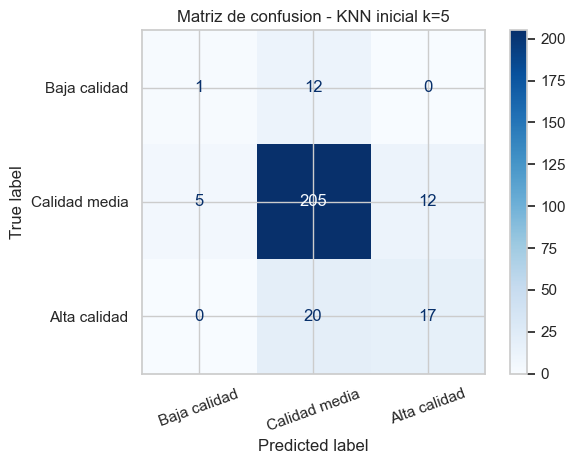

In [9]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    initial_predictions,
    display_labels=order,
    cmap="Blues",
    xticks_rotation=20,
)
plt.title(f"Matriz de confusion - KNN inicial k={initial_k}")
plt.tight_layout()
plt.show()

## 4. Optimizacion de k

In [10]:
def get_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

k_results = []

for k in range(1, 21):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=k)),
    ])
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    k_results.append({"k": k, **get_metrics(y_test, predictions)})

k_results_df = pd.DataFrame(k_results)
k_results_df.to_csv(K_RESULTS_PATH, index=False)

best_k = int(k_results_df.sort_values(["accuracy", "f1_weighted"], ascending=False).iloc[0]["k"])
print(f"Mejor k encontrado: {best_k}")
display(k_results_df.round(4))

Mejor k encontrado: 19


,k,accuracy,precision_weighted,recall_weighted,f1_weighted,f1_macro
0,1,0.7757,0.7912,0.7757,0.7816,0.5576
1,2,0.7941,0.7893,0.7941,0.7744,0.4880
2,3,0.8235,0.8017,0.8235,0.8113,0.5131
3,4,0.8125,0.7853,0.8125,0.7929,0.5148
4,5,0.8199,0.7937,0.8199,0.8042,0.5046
5,6,0.8125,0.7722,0.8125,0.7847,0.4374
6,7,0.8419,0.8075,0.8419,0.8225,0.5043
7,8,0.8309,0.7972,0.8309,0.8063,0.4730
8,9,0.8419,0.7985,0.8419,0.8139,0.4805
9,10,0.8272,0.7791,0.8272,0.7957,0.4495


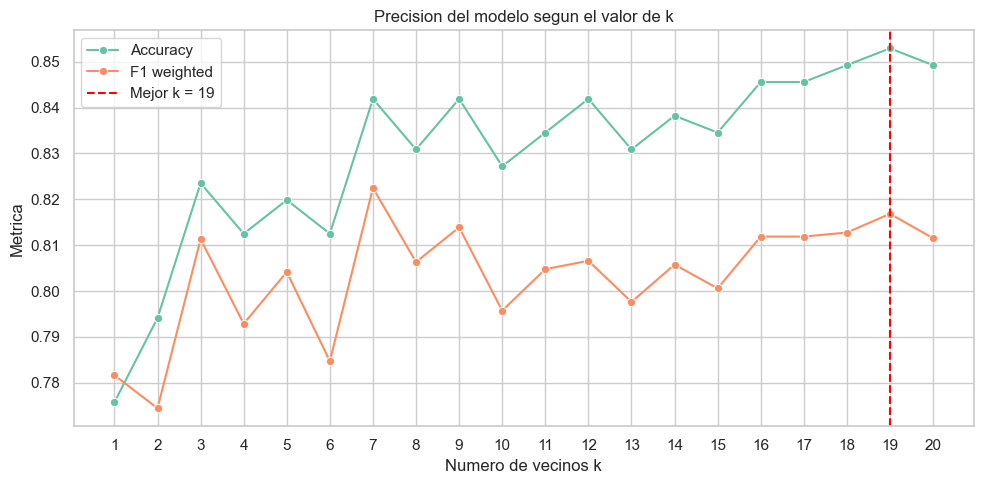

In [11]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=k_results_df, x="k", y="accuracy", marker="o", label="Accuracy")
sns.lineplot(data=k_results_df, x="k", y="f1_weighted", marker="o", label="F1 weighted")
plt.axvline(best_k, color="red", linestyle="--", label=f"Mejor k = {best_k}")
plt.title("Precision del modelo segun el valor de k")
plt.xlabel("Numero de vecinos k")
plt.ylabel("Metrica")
plt.xticks(range(1, 21))
plt.legend()
plt.tight_layout()
plt.show()

Accuracy KNN optimizado k=19: 0.8529
               precision    recall  f1-score   support

 Baja calidad       0.00      0.00      0.00        13
Calidad media       0.86      0.98      0.92       222
 Alta calidad       0.78      0.38      0.51        37

     accuracy                           0.85       272
    macro avg       0.55      0.45      0.48       272
 weighted avg       0.81      0.85      0.82       272



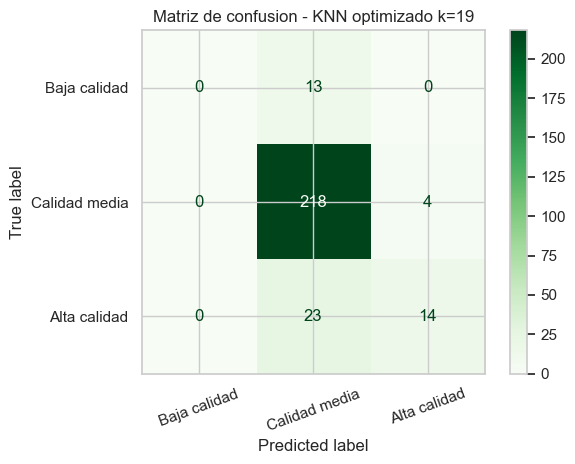

In [12]:
best_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=best_k)),
])

best_knn.fit(X_train, y_train)
best_knn_predictions = best_knn.predict(X_test)

print(f"Accuracy KNN optimizado k={best_k}: {accuracy_score(y_test, best_knn_predictions):.4f}")
print(classification_report(y_test, best_knn_predictions, target_names=order, zero_division=0))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_knn_predictions,
    display_labels=order,
    cmap="Greens",
    xticks_rotation=20,
)
plt.title(f"Matriz de confusion - KNN optimizado k={best_k}")
plt.tight_layout()
plt.show()

Tambien se prueba KNN con `weights="distance"`. En esta variante, los vecinos mas cercanos tienen mas peso que los mas lejanos, lo cual puede mejorar el resultado sin abandonar la familia KNN.

In [13]:
knn_distance = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=best_k, weights="distance")),
])

knn_distance.fit(X_train, y_train)
knn_distance_predictions = knn_distance.predict(X_test)

print(f"Accuracy KNN distance k={best_k}: {accuracy_score(y_test, knn_distance_predictions):.4f}")
print(classification_report(y_test, knn_distance_predictions, target_names=order, zero_division=0))

Accuracy KNN distance k=19: 0.8566
               precision    recall  f1-score   support

 Baja calidad       0.00      0.00      0.00        13
Calidad media       0.86      0.98      0.92       222
 Alta calidad       0.76      0.43      0.55        37

     accuracy                           0.86       272
    macro avg       0.54      0.47      0.49       272
 weighted avg       0.81      0.86      0.82       272



## 5. Comparacion con modelos de referencia

In [14]:
reference_models = {
    f"KNN k={best_k}": best_knn,
    f"KNN k={best_k} distance": knn_distance,
    "SVC RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(class_weight="balanced", random_state=42)),
    ]),
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1,
    ),
}

model_results = []
fitted_models = {}

for name, model in reference_models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model
    predictions = model.predict(X_test)
    model_results.append({"model": name, **get_metrics(y_test, predictions)})

model_results_df = pd.DataFrame(model_results).sort_values(["accuracy", "f1_weighted"], ascending=False)
model_results_df.to_csv(MODEL_RESULTS_PATH, index=False)
display(model_results_df.round(4))

,model,accuracy,precision_weighted,recall_weighted,f1_weighted,f1_macro
1,KNN k=19 distance,0.8566,0.8093,0.8566,0.8239,0.4898
0,KNN k=19,0.8529,0.8063,0.8529,0.8168,0.4750
3,RandomForest,0.8346,0.7821,0.8346,0.8037,0.4626
2,SVC RBF,0.6912,0.8364,0.6912,0.7290,0.5581


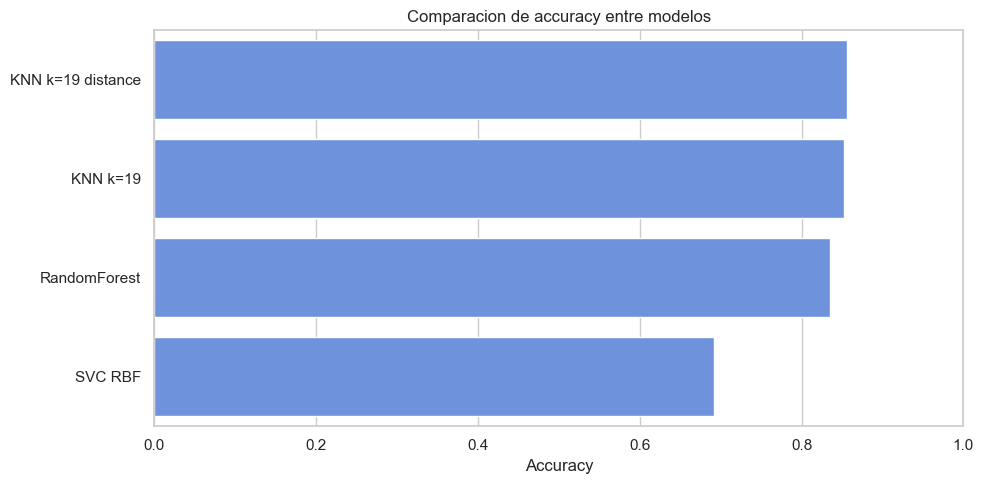

In [15]:
plt.figure(figsize=(10, 5))
sns.barplot(data=model_results_df, x="accuracy", y="model", color="#5B8DEF")
plt.title("Comparacion de accuracy entre modelos")
plt.xlabel("Accuracy")
plt.ylabel("")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

El modelo principal del proyecto es KNN. La comparacion con SVC y Random Forest sirve como referencia adicional para verificar si otra tecnica estudiada puede mejorar la clasificacion.

## 6. Guardado del modelo y funcion de prediccion

In [16]:
best_model_name = model_results_df.iloc[0]["model"]
best_model = fitted_models[best_model_name]

with KNN_MODEL_PATH.open("wb") as model_file:
    pickle.dump(knn_distance, model_file)

with BEST_MODEL_PATH.open("wb") as model_file:
    pickle.dump(best_model, model_file)

print(f"Modelo KNN guardado en: {KNN_MODEL_PATH}")
print(f"Mejor modelo global guardado en: {BEST_MODEL_PATH}")
print(f"Mejor modelo global: {best_model_name}")

Modelo KNN guardado en: /Users/dragcessa/Desktop/Dragcessa1998-Proyecto-K-vecinos-m-s-Cercanos-main/models/wine_quality_knn.pkl
Mejor modelo global guardado en: /Users/dragcessa/Desktop/Dragcessa1998-Proyecto-K-vecinos-m-s-Cercanos-main/models/wine_quality_best_model.pkl
Mejor modelo global: KNN k=19 distance


In [17]:
def predict_wine_quality(values, model=knn_distance):
    columns = feature_columns
    prediction = int(model.predict(pd.DataFrame([values], columns=columns))[0])
    messages = {
        0: "Este vino probablemente sea de baja calidad 🍷",
        1: "Este vino probablemente sea de calidad media 🍷",
        2: "Este vino probablemente sea de alta calidad 🍷",
    }
    return messages[prediction]

example_wine = [7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4]
predict_wine_quality(example_wine)

'Este vino probablemente sea de calidad media 🍷'

## Insight posteable

In [18]:
best_accuracy = model_results_df.iloc[0]["accuracy"]
post_text = (
    f"¿Puede la inteligencia artificial predecir la calidad de un vino? Entrene un modelo KNN con datos reales "
    f"del UCI ML Repo y alcance una precision aproximada del {best_accuracy:.1%}. "
    "El analisis muestra que variables como alcohol, sulfatos y acidez volatil ayudan a diferenciar vinos de baja, media y alta calidad. "
    "#MachineLearning #DataScience #WineQuality #KNN #IA"
)
print(post_text)

¿Puede la inteligencia artificial predecir la calidad de un vino? Entrene un modelo KNN con datos reales del UCI ML Repo y alcance una precision aproximada del 85.7%. El analisis muestra que variables como alcohol, sulfatos y acidez volatil ayudan a diferenciar vinos de baja, media y alta calidad. #MachineLearning #DataScience #WineQuality #KNN #IA


## Conclusiones

- KNN requiere escalado porque depende de distancias entre observaciones.
- La variable `quality` fue transformada en `label`: baja, media y alta calidad.
- El mejor valor de `k` se selecciono probando valores entre 1 y 20.
- La clase de calidad media domina el dataset, por lo que tambien se revisaron metricas como `f1_weighted` y `f1_macro`.
- El ejemplo proporcionado por el enunciado se clasifica como calidad media.
- Se guardaron el modelo KNN y el mejor modelo global en la carpeta `models/`.